<a href="https://colab.research.google.com/github/tort-cam/ST554HW7/blob/main/ST554HW7TEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Reading in the tools we'll need

In [85]:
pip install ucimlrepo

In [87]:
## Pulling in the data
from ucimlrepo import fetch_ucirepo
## The essentials
import numpy as np
import pandas as pd
import math
## Graphing
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
## Modeling & Regression
from sklearn import linear_model
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split, cross_validate
from scipy.stats import linregress
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import PolynomialFeatures

### Reading in our data

In [68]:
# fetch dataset
wine_quality = fetch_ucirepo(id=186)

In [69]:
wine = wine_quality.data['features'].copy()
wine['color'] = wine_quality.data['original']['color']
wine['quality'] = wine_quality.data['original']['quality']
wine['color'] = wine['color'].map({'red': 0, 'white': 1})

In [70]:
wine

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,color,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,0,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,1,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1,7


### Train and test split

In [71]:
cols = wine.columns.drop("alcohol")

x_train, x_test, y_train, y_test = train_test_split(
    wine[cols],
    wine['alcohol'],
    test_size = .2,
    random_state = 9,
    stratify = wine['color']
)

### Standardizing the training split

In [83]:
means = x_train.apply(np.mean, axis = 0)
stds = x_train.apply(np.std, axis = 0)

x_train = x_train.apply(lambda x: (x-np.mean(x))/np.std(x), axis = 0)
x_train.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,color,quality
count,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03,5.197000e+03
mean,-8.203303e-18,2.734434e-18,-6.836086e-19,2.119187e-17,-2.358450e-17,1.367217e-17,8.203303e-18,6.836086e-18,2.460991e-17,-6.836086e-18,-3.178780e-17,5.810673e-18
std,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00,1.000096e+00
min,-2.655375e+00,-1.582749e+00,-2.226657e+00,-1.018009e+00,-1.302397e+00,-1.644949e+00,-1.932224e+00,-2.526757e+00,-2.960377e+00,-2.074426e+00,-1.750237e+00,-3.224840e+00
25%,-6.355791e-01,-6.720074e-01,-4.770658e-01,-7.660517e-01,-5.033603e-01,-7.518265e-01,-6.827389e-01,-7.721183e-01,-6.667797e-01,-6.714686e-01,5.713511e-01,-9.423076e-01
50%,-1.694723e-01,-3.077106e-01,-5.716387e-02,-4.930977e-01,-2.553834e-01,-8.198483e-02,3.879466e-02,6.025298e-02,-4.688844e-02,-1.370087e-01,5.713511e-01,1.989584e-01
75%,3.743190e-01,4.208830e-01,5.027054e-01,5.567254e-01,2.405704e-01,5.878569e-01,6.899347e-01,7.394679e-01,6.349919e-01,4.642587e-01,5.713511e-01,1.989584e-01
max,6.744445e+00,6.006767e+00,6.381333e+00,1.267168e+01,1.528450e+01,1.443125e+01,5.705473e+00,1.474328e+01,4.912241e+00,9.817307e+00,5.713511e-01,3.622756e+00


Below, I am just making a quick collection of every variable plotted against alcohol. This helps provide a general idea of which variables may be most useful.

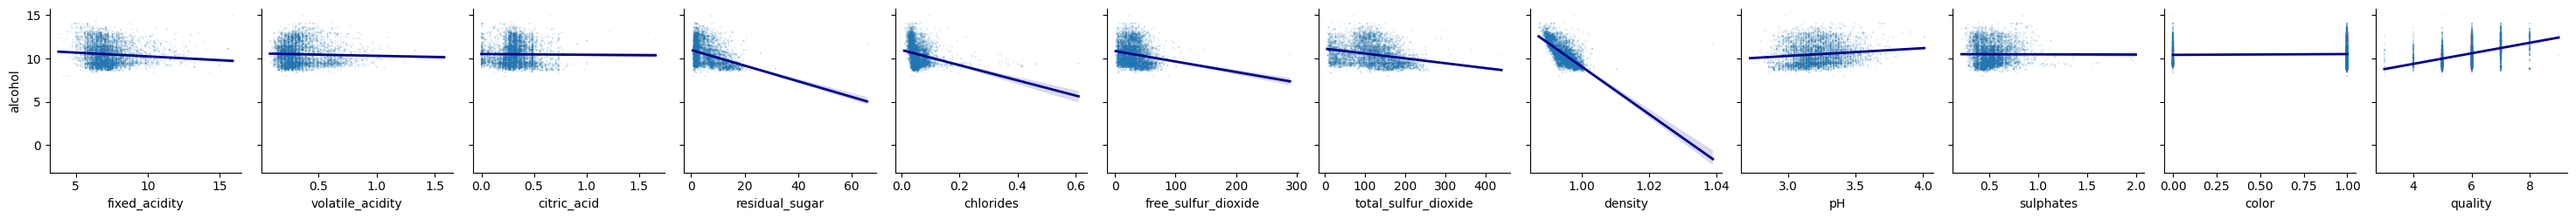

In [103]:
notB = wine.columns.drop(["alcohol"])
every = sns.pairplot(kind = "reg", data = wine, y_vars = "alcohol", x_vars = notB, markers = "+",\
                    plot_kws = {'line_kws':{'lw' : 2, 'color':"darkblue"}, 'scatter_kws':{'alpha':.1, 's':2}})

### Model Setup

In [114]:
poly = PolynomialFeatures(degree = 2, interaction_only = True, include_bias = False)
poly2 = PolynomialFeatures(degree = 2, include_bias = False)

pipeline = Pipeline([
    ('interactions', poly),
    ('model', LinearRegression())
])
pipeline2 = Pipeline([
    ('interactions', poly2),
    ('model', LinearRegression())
])

In [124]:
## Full Model, includes color & quality
cv_full_mlr = cross_validate(
    LinearRegression(),
    x_train,
    y_train,
    cv = 5,
    scoring = "neg_mean_squared_error")

## Medium-size model with interaction term
cv_med_int_mlr = cross_validate(
    pipeline,
    x_train[['density', 'residual_sugar', 'total_sulfur_dioxide', 'quality']],
    y_train,
    cv = 5,
    scoring = "neg_mean_squared_error")

## Small model with polynomial term - Chosen based on early plot
cv_small_int_mlr = cross_validate(
    pipeline2,
    x_train[['density', 'residual_sugar']],
    y_train,
    cv = 5,
    scoring = "neg_mean_squared_error")

## Smaller model, only includes a few variables - Chosen based on early plot
cv_small_mlr = cross_validate(
    LinearRegression(),
    x_train[['density', 'residual_sugar']],
    y_train,
    cv = 5,
    scoring = "neg_mean_squared_error")



In [125]:
print("MLR Models RMSE:\n" +
      "Full simple model: \t"+ str(np.sqrt(-sum(cv_full_mlr['test_score']))) + "\n" +
      "Medium interaction: \t"+ str(np.sqrt(-sum(cv_med_int_mlr['test_score']))) + "\n" +
      "Small polynomial: \t"+ str(np.sqrt(-sum(cv_small_int_mlr['test_score']))) + "\n" +
      "Small: \t\t\t"+ str(np.sqrt(-sum(cv_small_mlr['test_score']))))

MLR Models RMSE:
Full simple model: 	1.1594887389353608
Medium interaction: 	1.7118070497102205
Small polynomial: 	1.6136845111301221
Small: 			1.9468913155026373


From this print statement, we can see that to no surprise, the full simple model is best.